# Chapter 4: Data Visualization

In [135]:
#!pip install matplotlib

In [136]:
low_memory=False
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 4.1 Introduction & Problem Setting

In this lesson we are going to go over the basics of plotting in python. For this we will use the matplotlib library. There are other libraries (seaborn, plotnine, ...) that offer different types of functionality and other programming languages more suited to data visualisation (e.g. ggplot2 in R), but let's take the path of least resistence for now.

For those of you who are interested in the specifics of including local/web images in your jupyter notebook: consult the StackOverflow article at https://stackoverflow.com/questions/32370281/how-to-embed-image-or-picture-in-jupyter-notebook-either-from-a-local-machine-o

Those interested in markdown and the link to html, visit https://www.xaprb.com/blog/how-to-style-images-with-markdown/

## 4.2 Basic Data Visualization

Before we get started with visualizing our first plots, remember that the internet is a beautiful place! There are plenty of tutorials out there which offer a unique view on the subject. Some excellent examples are [this tutorial](https://www.skytowner.com/explore/getting_started_with_matplotlib) or the official [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html).

Now, let's get started by plotting a simple data point!

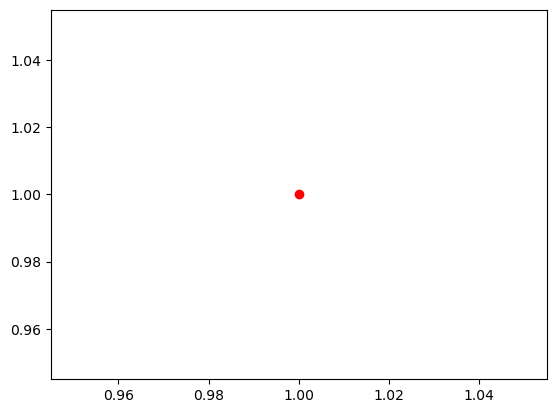

In [137]:
# plot a single point at coordinates (1,1) in red
plt.scatter(1, 1, color = 'r')

plt.scatter(1, 1, color = 'r')

We can easily add a second point to our visualization by passing it to the function.

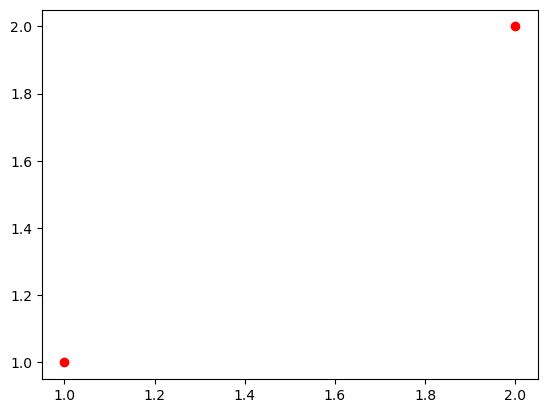

In [138]:
# plot two points at (1,1) and (2,2) in red
plt.scatter([1,2],[1,2], color = 'r')

Function Arguments:

- [1,2] (first argument) — The x-coordinates; creates points at x-positions 1 and 2
- [1,2] (second argument) — The y-coordinates; creates points at y-positions 1 and 2
-  color = 'r' — Sets the point color to red; you can use abbreviations like 'r' (red), 'b' (blue), 'g' (green), or named colors like 'gold', 'orange', etc.

Result: This creates a scatter plot with two points:
- One point at coordinates (1, 1)
- One point at coordinates (2, 2)

We can also play around with the colour!

There are multiple options available. You can use a lot of abbreviations (such as 'r' for red), RGBA codes, HEX codes or even common css named colours.

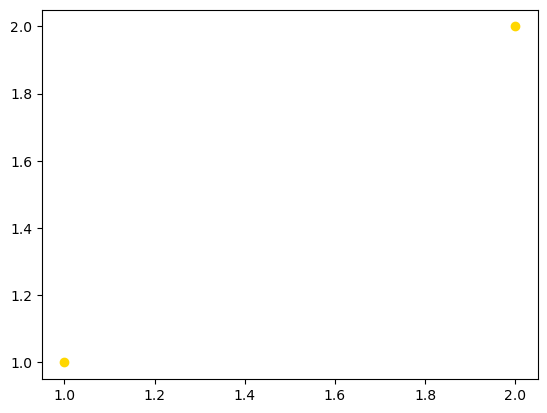

In [139]:
plt.scatter([1,2],[1,2], color = 'gold')

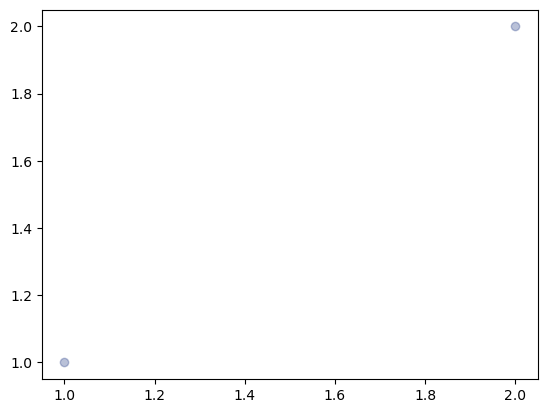

In [140]:
plt.scatter([1,2],[1,2], color = (0.1, 0.2, 0.5, 0.3))

Right now we are working in a **scatterplot**. This works great for visualizing seperate data points. But what do we do if we want to show an evolution of data and we want to connect the dots?

Instead of remaining in our plot.scatter world, we use plt.plot! This allows us to draw lines with ease.

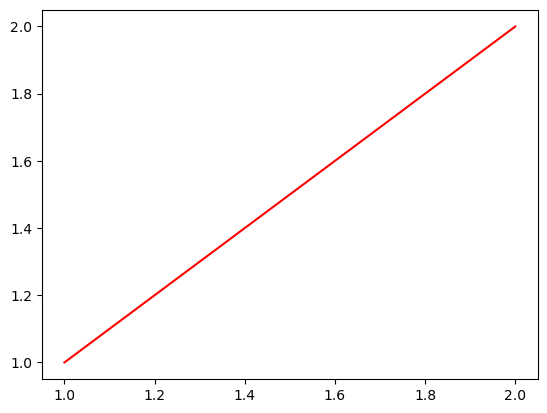

In [141]:
plt.plot([1,2],[1,2], color = 'r')

Everything we've seen so far is good for basic visualizations, but when it comes to proper data plotting, we need a bit more structure. Luckily, there is already a defined structure for us to use: the figure and axes system!

A visualization is called a **Figure**. Each figure can contain multiple plots, which we call **axes** (these are different from the x and y **axis** in your plot; think of axes as individual chart areas and axis as the number lines). Please study the diagram below to understand the structure.

![](https://storage.googleapis.com/skytowner_public/images/uG4nzrYfQ9KDk2M87YDI/matplotlib_figure_axes_axis%20(4).png)

Let's try this out! Just as we've done before, we'll store the output of our plot in a variable so we can use it later. We'll create one figure with a single axes containing a simple plot with two data points.

Normally, when we run our code, it will display the output instantly. To prevent this, simply add 'plt.close()' *after* your plot code.

In [143]:
# create a new figure and add one axes object
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
# draw two blue points on that axes

ax.scatter([1,2],[1,2], color = 'b')
plt.close()
# close the figure so it does not display automatically

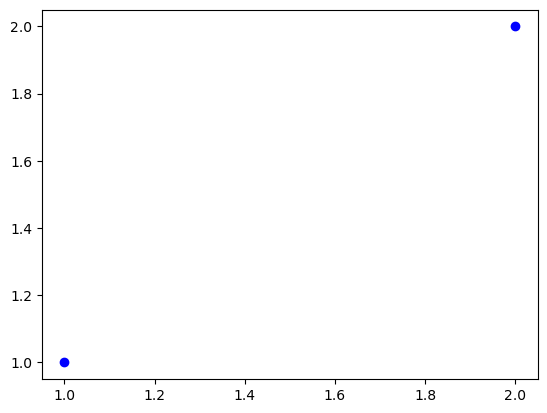

In [ ]:
fig

#### Question 1: Create a new plot with two axes: the one from the plot above and the one where we drew the line. Can you arrange them next to each other? What if you put them below each other instead?

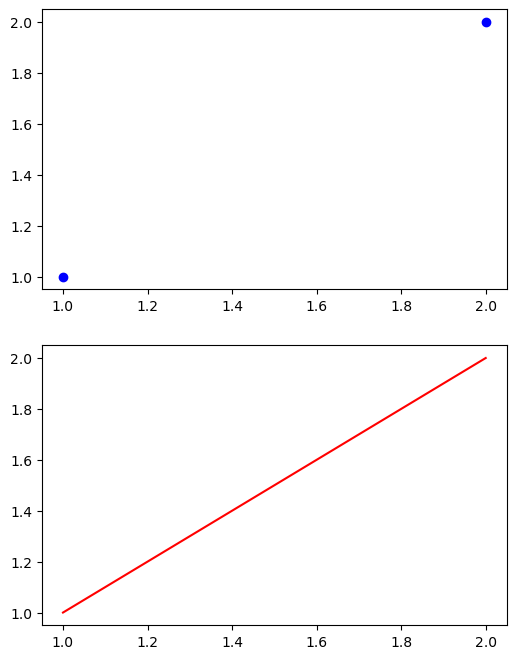

In [ ]:
# create a figure with two subplots stacked vertically
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(2,1,1)
ax.scatter([1,2],[1,2], color = 'b')
ax2 = fig.add_subplot(2,1,2)
ax2.plot([1,2],[1,2], color = 'r')

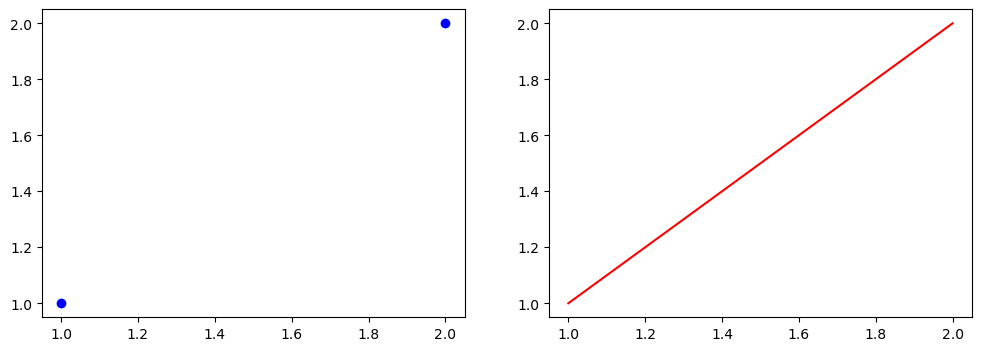

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,2,1)
ax.scatter([1,2],[1,2], color = 'b')
ax2 = fig.add_subplot(1,2,2)
ax2.plot([1,2],[1,2], color = 'r')

### 4.2.1 Data Reading
Let's start by looking at some actual data. There are three files with weather station data (extracted from [ncdc.noaa.gov](https://www.ncdc.noaa.gov/cdo-web/search)) on Canvas called '72356013968.csv', '72546014933.csv', and '72450003928.csv'. Download them and place them in the same directory as this notebook.

#### Question 2: Recap! Load all three CSV files into memory. Check the number of columns and records. Can you see a potential issue? Merge the top 100 records from each dataframe into a single new dataframe.

In [ ]:
station1 = pd.read_csv("72546014933.csv", sep = ";")
print(station1.shape)
station1.head() 

(12771, 109)


C:\Users\billo\AppData\Local\Temp\ipykernel_20608\900223362.py:1: DtypeWarning: Columns (44,45,46,51,62,63,68) have mixed types. Specify dtype option on import or set low_memory=False.
  station1 = pd.read_csv("72546014933.csv", sep = ";")


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,OD1,OE1,OE2,OE3,RH1,RH2,RH3,WA1,REM,EQD
0,72546014933,19/07/2024 0:00,4,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-12,99999,V020,...,"4,99,0088,1,999",NaN,NaN,NaN,NaN,NaN,NaN,NaN,SYN09272546 12464 83511 10000 21017 39763 4012...,NaN
1,72546014933,20/07/2024 0:00,7,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-15,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET12612/31/18 18:54:01 METAR KDSM 010054Z 340...,NaN
2,72546014933,21/07/2024 0:00,7,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-16,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET10312/31/18 19:17:01 SPECI KDSM 010117Z 340...,NaN
3,72546014933,22/07/2024 0:00,7,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-16,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,000,9,9",MET13612/31/18 19:27:01 SPECI KDSM 010127Z 320...,NaN
4,72546014933,23/07/2024 0:00,7,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-16,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,000,9,9",MET13112/31/18 19:38:01 SPECI KDSM 010138Z 310...,NaN


In [ ]:
# read the second station file and inspect its shape and first rows
station2 = pd.read_csv("72450003928.csv", sep = ";")
print(station2.shape)
station2.head() 

C:\Users\billo\AppData\Local\Temp\ipykernel_20608\1683525731.py:2: DtypeWarning: Columns (19,22,23,24,25,26,27,28,29,30,31,32,33,46,50,55,56,62,82,83,93,96) have mixed types. Specify dtype option on import or set low_memory=False.
  station2 = pd.read_csv("72450003928.csv", sep = ";")


(11710, 108)


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,OD1,OE1,OE2,OE3,RH1,RH2,RH3,WA1,REM,EQD
0,72450003928,10/04/2024 0:00,4,3764753,-9742999,4017,"WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT,...",FM-12,99999,V020,...,"4,99,0124,1,999",NaN,NaN,NaN,NaN,NaN,NaN,NaN,SYN08672450 32964 63616 10056 21039 39547 4002...,NaN
1,72450003928,11/04/2024 0:00,4,3764753,-9742999,4017,"WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT,...",FM-15,99999,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET086METAR KICT 010053Z 36017G25KT 8SM BKN150...,NaN
2,72450003928,12/04/2024 0:00,4,3764753,-9742999,4017,"WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT,...",FM-15,99999,V020,...,"4,99,0144,1,010",NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET107METAR KICT 010153Z 01015G23KT 5SM HZ BKN...,NaN
3,72450003928,13/04/2024 0:00,4,3764753,-9742999,4017,"WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT,...",FM-15,99999,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET093METAR KICT 010253Z 02016KT 5SM HZ SCT120...,NaN
4,72450003928,14/04/2024 0:00,4,3764753,-9742999,4017,"WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT,...",FM-16,99999,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET084SPECI KICT 010336Z 02015KT 7SM BKN012 BK...,NaN


In [ ]:
# read the third station file and inspect its shape and first rows
station3 = pd.read_csv("72356013968.csv", sep = ";")
print(station3.shape)
station3.head()

C:\Users\billo\AppData\Local\Temp\ipykernel_20608\363154915.py:2: DtypeWarning: Columns (43,44,48,49,54,55,56,59,60,64,91,102) have mixed types. Specify dtype option on import or set low_memory=False.
  station3 = pd.read_csv("72356013968.csv", sep = ";")


(12139, 105)


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,OD1,OE1,OE2,OE3,RH1,RH2,RH3,WA1,REM,EQD
0,72356013968,1/01/2024 0:00,4.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-12,99999,V020,...,"4,99,0103,1,999",NaN,NaN,NaN,NaN,NaN,NaN,NaN,SYN08672356 32466 80114 10006 21033 30002 4025...,NaN
1,72356013968,2/01/2024 0:00,7.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-15,KTUL,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET09912/31/23 18:53:03 METAR KTUL 010053Z 010...,NaN
2,72356013968,3/01/2024 0:00,7.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-15,KTUL,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET09912/31/23 19:53:03 METAR KTUL 010153Z 360...,NaN
3,72356013968,4/01/2024 0:00,7.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-15,KTUL,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET10512/31/23 20:53:03 METAR KTUL 010253Z 010...,NaN
4,72356013968,5/01/2024 0:00,4.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-12,99999,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SYN06472356 32566 80111 10011 21039 30018 4027...,NaN


In [ ]:
station_list = [station1.iloc[:100, :], station2.iloc[:100, :], station3.iloc[:100, :]]

station_data = pd.concat(station_list)
station_data

,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,OE2,OE3,RH1,RH2,RH3,WA1,REM,EQD,MW3,AW7
0,72546014933,19/07/2024 0:00,4.0,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-12,99999,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,SYN09272546 12464 83511 10000 21017 39763 4012...,NaN,NaN,NaN
1,72546014933,20/07/2024 0:00,7.0,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-15,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET12612/31/18 18:54:01 METAR KDSM 010054Z 340...,NaN,NaN,NaN
2,72546014933,21/07/2024 0:00,7.0,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-16,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET10312/31/18 19:17:01 SPECI KDSM 010117Z 340...,NaN,NaN,NaN
3,72546014933,22/07/2024 0:00,7.0,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-16,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,"9,000,9,9",MET13612/31/18 19:27:01 SPECI KDSM 010127Z 320...,NaN,NaN,NaN
4,72546014933,23/07/2024 0:00,7.0,415338,-93653,2917,"DES MOINES INTERNATIONAL AIRPORT, IA US",FM-16,KDSM,V030,...,NaN,NaN,NaN,NaN,NaN,"9,000,9,9",MET13112/31/18 19:38:01 SPECI KDSM 010138Z 310...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,72356013968,5/04/2024 0:00,7.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-15,KTUL,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09501/03/24 13:53:02 METAR KTUL 031953Z 360...,NaN,NaN,NaN
96,72356013968,6/04/2024 0:00,7.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-15,KTUL,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET10101/03/24 14:53:02 METAR KTUL 032053Z 010...,NaN,NaN,NaN
97,72356013968,7/04/2024 0:00,4.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-12,99999,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,SYN06472356 32966 00105 10111 20000 39952 4020...,NaN,NaN,NaN
98,72356013968,8/04/2024 0:00,7.0,3619854,-9587825,1949,"TULSA INTERNATIONAL AIRPORT, OK US",FM-15,KTUL,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09501/03/24 15:53:02 METAR KTUL 032153Z 350...,NaN,NaN,NaN


In [ ]:
station_data.shape

(300, 111)

Originally, the datasets each have 111 columns and about 12,500 rows. If we merged all of them, our final dataset would be about 37,500 records long. Not only would this make the data difficult to visualize, but it would also significantly slow down our computer's performance.

## 4.3 Plotting the Data


Just as we structured our figure into separate axes, we can organize each individual plot. Study the image below to understand what elements we can control.

![](https://storage.googleapis.com/skytowner_public/images/uG4nzrYfQ9KDk2M87YDI/Anatomy_1.png)

We can now easily plot this data using the methods we've seen above.

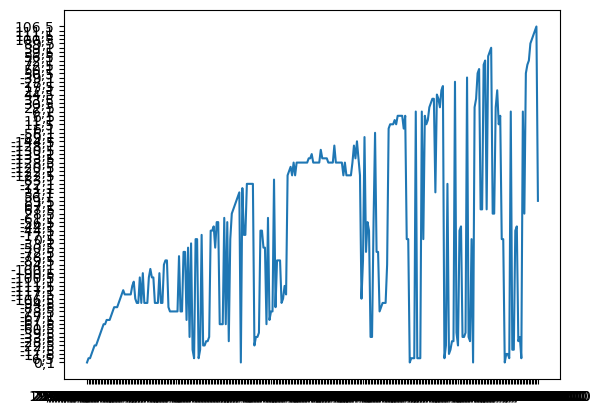

In [ ]:
plt.plot(station_data['DATE'], station_data['TMP'])

Wait, this looks terrible! What's going on? The data points are completely unreadable, and we cannot see any difference between our separate stations. We can fix this by extracting the data from each station separately and layering them together!

### 4.3.1 Plotting Layer by Layer


First, let's check how many different stations our dataset contains and how many records each station has. We should have 3 × 100 records since we just combined our dataset, but it's always good to verify!

In [ ]:
station_data.groupby(['STATION', 'NAME']).size()

STATION      NAME                                                
72356013968  TULSA INTERNATIONAL AIRPORT, OK US                      100
72450003928  WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT, KS US    100
72546014933  DES MOINES INTERNATIONAL AIRPORT, IA US                 100
dtype: int64

Excellent! We can even see the station names! Now let's create a few separate series, two for each station. We need two per station because we want to display something on the x-axis (date) and something on the y-axis (temperature).

In [ ]:
# extract separate date and temperature series for each station id
TU_date = station_data[station_data['STATION'] == 72356013968]['DATE']
TU_temp = station_data[station_data['STATION'] == 72356013968]['TMP']

WI_date = station_data[station_data['STATION'] == 72450003928]['DATE']
WI_temp = station_data[station_data['STATION'] == 72450003928]['TMP']

DM_date = station_data[station_data['STATION'] == 72546014933]['DATE']
DM_temp = station_data[station_data['STATION'] == 72546014933]['TMP']

In [ ]:
TU_date

0     1/01/2024 0:00
1     2/01/2024 0:00
2     3/01/2024 0:00
3     4/01/2024 0:00
4     5/01/2024 0:00
           ...      
95    5/04/2024 0:00
96    6/04/2024 0:00
97    7/04/2024 0:00
98    8/04/2024 0:00
99    9/04/2024 0:00
Name: DATE, Length: 100, dtype: object

And now we can plot this. Remember to give each station its own colour!

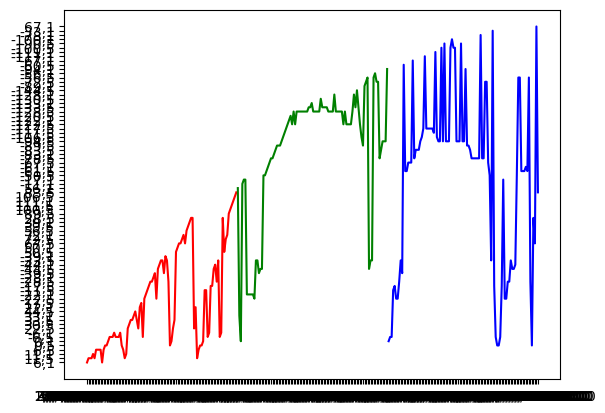

In [ ]:
# plot all three station temperature series on the same figure using different colours
plt.plot(TU_date, TU_temp, color = 'r')
plt.plot(WI_date, WI_temp, color = 'g')
plt.plot(DM_date, DM_temp, color = 'b')
plt.show()

### 4.3.2 Issues with Our Plot

Currently we have a plot, but it is not very appealing. There are still several issues we can find here.

#### Question 3: What can we improve on our plot above?

Some improvements we can make:
- Adding a title
- Adding a legend
- Labeling the axes
- Improving readability of the x-axis
- Improving readability of the y-axis

Before we continue, did you notice that the temperature and dates weren't recognized as their proper data types and didn't display correctly? If not, that's another thing to improve on the plot!

Now we need to convert these columns. While we're at it, let's also convert the temperature from Fahrenheit to Celsius.

In [ ]:
# convert temperature column from string with comma decimal to float
station_data['TMP'] = station_data['TMP'].str.replace(',', '.').astype(float)

In [ ]:
# convert date strings to datetime objects and change temperatures from F to C
TU_date = pd.to_datetime(station_data[station_data['STATION'] == 72356013968]['DATE'], format='%d/%m/%Y %H:%M')
TU_temp = (5/9)*(station_data[station_data['STATION'] == 72356013968]['TMP'] - 32)

WI_date = pd.to_datetime(station_data[station_data['STATION'] == 72450003928]['DATE'], format='%d/%m/%Y %H:%M')
WI_temp = (5/9)*(station_data[station_data['STATION'] == 72450003928]['TMP']  -32)

DM_date = pd.to_datetime(station_data[station_data['STATION'] == 72546014933]['DATE'], format='%d/%m/%Y %H:%M')
DM_temp = (5/9)*(station_data[station_data['STATION'] == 72546014933]['TMP'] -32)

Now it's time to improve the plot! We'll do this by adding a title, labeling the axes, adding a legend, and including a small grid to improve readability. You'll notice that Python will automatically organize all our data on the axes now that we've converted it to the correct data types.

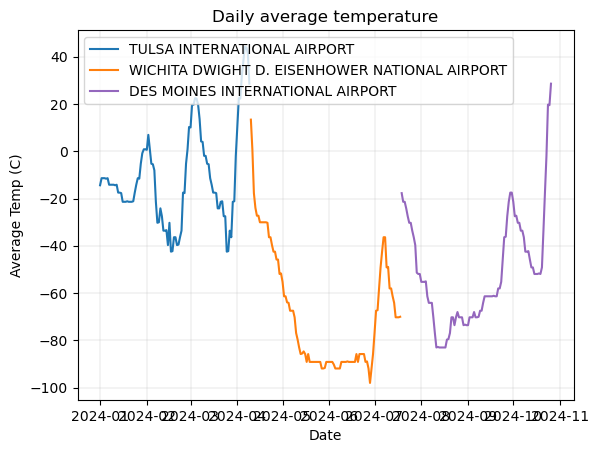

In [ ]:
# draw a cleaner multi-series line plot with titles and legend
plt.figure()
plt.plot(TU_date, TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
plt.plot(WI_date, WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
plt.plot(DM_date, DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Average Temp (C)')
plt.title('Daily average temperature')
plt.grid(linewidth=0.2)

### 4.3.3 Dots or Lines?

What's better: dots or lines? It depends on the situation.

Theoretically, lines "invent" data that doesn't actually exist when you connect data points. For this reason, a **scatter plot** is generally preferred. When your dataset is large, it still clearly communicates the message.

When your dataset is smaller, particularly when you zoom in on a specific section, a scatter plot becomes less informative. In those cases, a **line plot** might work better.

Of course, the choice between them isn't always clear-cut. Ultimately, the most important thing is the **story you want to tell** with your data. Your graph should support that story as clearly as possible while still showing the truth in your data.

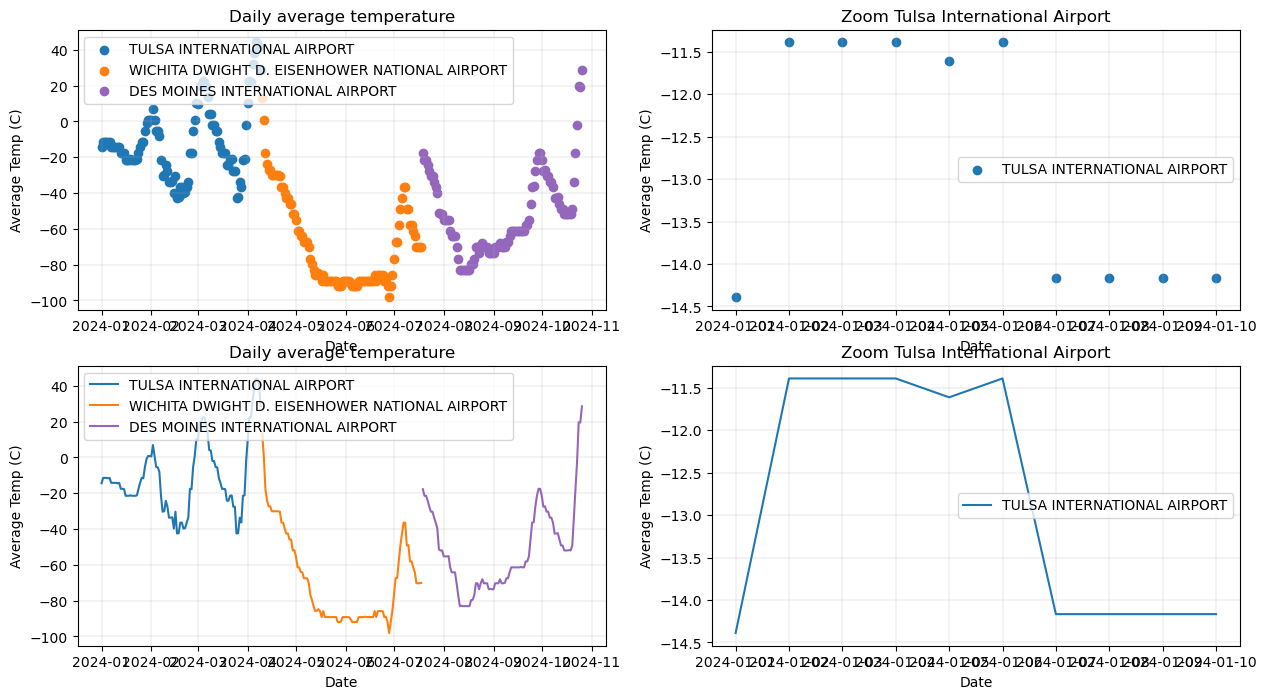

In [ ]:
# create a 2x2 grid of subplots to compare scatter and line versions with zoomed-in views
fig = plt.figure(figsize=(15,8))

ax1 = fig.add_subplot(2,2,1)
ax1.scatter(TU_date,TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
ax1.scatter(WI_date,WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
ax1.scatter(DM_date,DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')
ax1.legend()
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Temp (C)')
ax1.set_title('Daily average temperature')
ax1.grid(linewidth=0.2)

ax2 = fig.add_subplot(2,2,2)
ax2.scatter(TU_date[0:10],TU_temp[0:10], color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
ax2.legend()
ax2.set_xlabel('Date')
ax2.set_ylabel('Average Temp (C)')
ax2.set_title('Zoom Tulsa International Airport')
ax2.grid(linewidth=0.2)

ax3 = fig.add_subplot(2,2,3)
ax3.plot(TU_date,TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
ax3.plot(WI_date,WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
ax3.plot(DM_date,DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')
ax3.legend()
ax3.set_xlabel('Date')
ax3.set_ylabel('Average Temp (C)')
ax3.set_title('Daily average temperature')
ax3.grid(linewidth=0.2)

ax4 = fig.add_subplot(2,2,4)
ax4.plot(TU_date[0:10],TU_temp[0:10], color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
ax4.legend()
ax4.set_xlabel('Date')
ax4.set_ylabel('Average Temp (C)')
ax4.set_title('Zoom Tulsa International Airport')
ax4.grid(linewidth=0.2)

## 4.4 Adding Polish to Your Plots

Our plot is starting to look much better! Now let's add some finishing touches. How about a more professional title and a line showing the average temperature for each station?

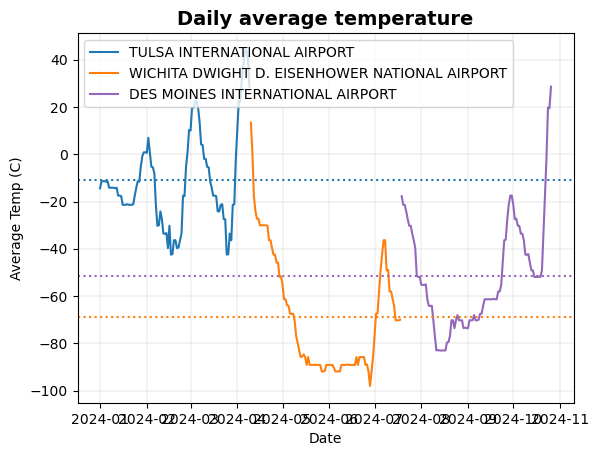

In [ ]:
plt.figure()
plt.plot(TU_date, TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
plt.plot(WI_date, WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
plt.plot(DM_date, DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Average Temp (C)')
plt.title('Daily average temperature', fontsize = 14, fontweight ='bold')
plt.grid(linewidth=0.2)
plt.axhline(TU_temp.mean(), color = 'tab:blue', linestyle = "dotted")  #horizontal line
plt.axhline(WI_temp.mean(), color = 'tab:orange', linestyle = "dotted")  #horizontal line
plt.axhline(DM_temp.mean(), color = 'tab:purple', linestyle = "dotted")  #horizontal line

Excellent! If you want to emphasize the data from Wichita Dwight D. Eisenhower National Airport, you can do so by adjusting the opacity (transparency) of the other plots.

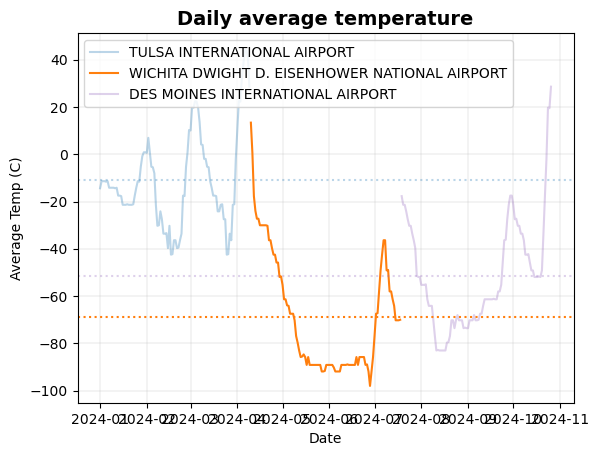

In [ ]:
plt.figure()
plt.plot(TU_date, TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT', alpha = 0.3)
plt.plot(WI_date, WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
plt.plot(DM_date, DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT', alpha = 0.3)
plt.legend()
plt.xlabel('Date')
plt.ylabel('Average Temp (C)')
plt.title('Daily average temperature', fontsize = 14, fontweight ='bold')
plt.grid(linewidth=0.2)
plt.axhline(TU_temp.mean(), color = 'tab:blue', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(WI_temp.mean(), color = 'tab:orange', linestyle = "dotted")  #horizontal line
plt.axhline(DM_temp.mean(), color = 'tab:purple', linestyle = "dotted", alpha = 0.3)  #horizontal line

Temperature always varies slightly throughout a day. Since we don't have this information in our dataset, let's assume it fluctuates about 20 degrees Fahrenheit in each direction on any given day. Can we visualize this variation in our plot?

In [ ]:
# assume a ±20°F daily fluctuation and compute min/max bounds in °C
TU_sd_min = (5/9)*(station_data[station_data['STATION'] == 72356013968]['TMP'] - 20 - 32)
TU_sd_max = (5/9)*(station_data[station_data['STATION'] == 72356013968]['TMP'] + 20 - 32)

WI_sd_min = (5/9)*(station_data[station_data['STATION'] == 72450003928]['TMP'] - 20 - 32)
WI_sd_max = (5/9)*(station_data[station_data['STATION'] == 72450003928]['TMP'] + 20 - 32)

DM_sd_min = (5/9)*(station_data[station_data['STATION'] == 72546014933]['TMP'] - 20 - 32)
DM_sd_max = (5/9)*(station_data[station_data['STATION'] == 72546014933]['TMP'] + 20 - 32)

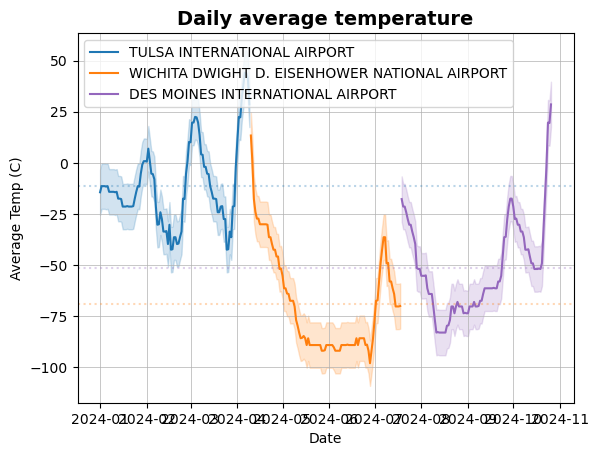

In [ ]:
plt.figure()
plt.plot(TU_date, TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
plt.plot(WI_date, WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
plt.plot(DM_date, DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')

plt.fill_between(TU_date, TU_sd_min, TU_sd_max, color = 'tab:blue', alpha = 0.2)
plt.fill_between(WI_date, WI_sd_min, WI_sd_max, color = 'tab:orange', alpha = 0.2)
plt.fill_between(DM_date, DM_sd_min, DM_sd_max, color = 'tab:purple', alpha = 0.2)

plt.legend()
plt.xlabel('Date')
plt.ylabel('Average Temp (C)')
plt.title('Daily average temperature', fontsize = 14, fontweight ='bold')
plt.grid(linewidth=0.5)
plt.axhline(TU_temp.mean(), color = 'tab:blue', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(WI_temp.mean(), color = 'tab:orange', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(DM_temp.mean(), color = 'tab:purple', linestyle = "dotted", alpha = 0.3)  #horizontal line

Now let's improve those hard-to-read dates. We can create a set of dates using pandas and format them as month names for better readability!

In [ ]:
pd.date_range(start='2024-01-01', end='2024-10-31', freq='1ME')

DatetimeIndex(['2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30',
               '2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31'],
              dtype='datetime64[ns]', freq='ME')

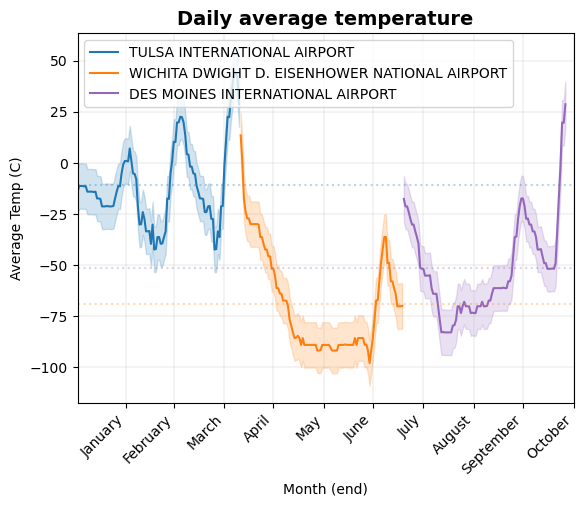

In [ ]:
plt.figure()
plt.plot(TU_date, TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
plt.plot(WI_date, WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
plt.plot(DM_date, DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')

plt.fill_between(TU_date, TU_sd_min, TU_sd_max, color = 'tab:blue', alpha = 0.2)
plt.fill_between(WI_date, WI_sd_min, WI_sd_max, color = 'tab:orange', alpha = 0.2)
plt.fill_between(DM_date, DM_sd_min, DM_sd_max, color = 'tab:purple', alpha = 0.2)

plt.legend()
plt.xlabel('Month (end)')
plt.ylabel('Average Temp (C)')
plt.title('Daily average temperature', fontsize = 14, fontweight ='bold')
plt.xlim([TU_date.min(), TU_date.max()])
plt.xticks(ticks = pd.to_datetime(pd.date_range(start='2024-01-01', end='2024-10-31', freq='1ME')), 
           labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October'], rotation=45, ha = 'right')
plt.grid(linewidth=0.2)
plt.axhline(TU_temp.mean(), color = 'tab:blue', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(WI_temp.mean(), color = 'tab:orange', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(DM_temp.mean(), color = 'tab:purple', linestyle = "dotted", alpha = 0.3)  #horizontal line

### 4.4.1 Additional Annotations

You can get very creative with plot annotations! For example, you can draw a vertical line similar to the average temperature line. You can even create a shaded zone to highlight a specific time period!

Text(2024-06-25 00:00:00, 0, '4th of July preparations')

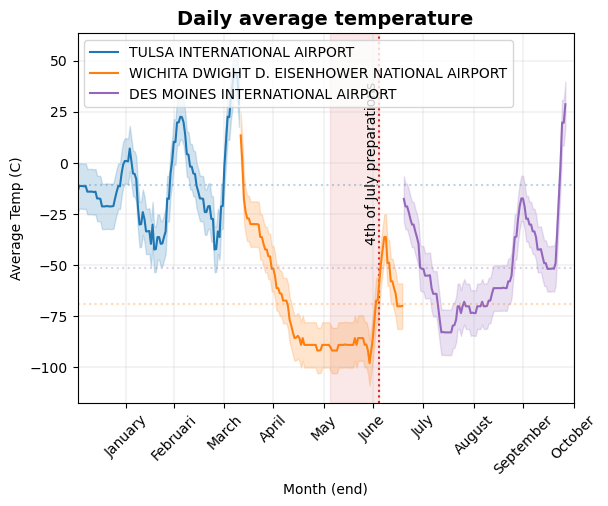

In [ ]:
plt.figure()
plt.plot(TU_date, TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
plt.plot(WI_date, WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
plt.plot(DM_date, DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')

plt.fill_between(TU_date, TU_sd_min, TU_sd_max, color = 'tab:blue', alpha = 0.2)
plt.fill_between(WI_date, WI_sd_min, WI_sd_max, color = 'tab:orange', alpha = 0.2)
plt.fill_between(DM_date, DM_sd_min, DM_sd_max, color = 'tab:purple', alpha = 0.2)

plt.legend()
plt.xlabel('Month (end)')
plt.ylabel('Average Temp (C)')
plt.title('Daily average temperature', fontsize = 14, fontweight ='bold')
plt.xlim([TU_date.min(), TU_date.max()])
plt.xticks(ticks = pd.to_datetime(pd.date_range(start='2024-01-01', end='2024-10-31', freq='1ME')), 
           labels = ['January', 'Februari', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October'], rotation=45)
plt.grid(linewidth=0.2)

plt.axhline(TU_temp.mean(), color = 'tab:blue', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(WI_temp.mean(), color = 'tab:orange', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(DM_temp.mean(), color = 'tab:purple', linestyle = "dotted", alpha = 0.3)  #horizontal line

plt.axvline(pd.to_datetime('2024-07-04'), zorder = 0,color = 'tab:red', linestyle = "dotted")  #vertical line
plt.axvspan(pd.to_datetime('2024-06-04'), pd.to_datetime('2024-07-04'), zorder = 0, color = 'tab:red', alpha = 0.1)  #vertical shading
plt.annotate("4th of July preparations", (pd.to_datetime('2024-06-25'), 0), rotation='vertical', ha = 'left', va = 'center')

### 4.4.2 Considering People with Color Blindness

When creating a plot, something obvious to you might not be clear to others. An important consideration is that many people around the world have some form of color blindness, and we should make our visualizations accessible to them.

First, let's save our figure using `plt.savefig()`.

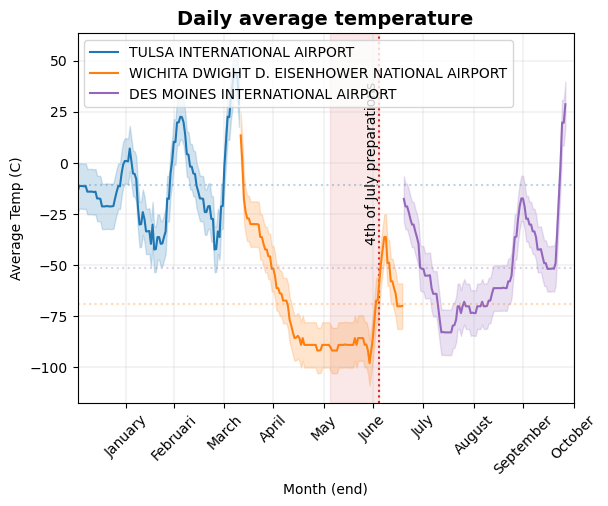

In [ ]:
plt.figure()
plt.plot(TU_date, TU_temp, color = 'tab:blue', label='TULSA INTERNATIONAL AIRPORT')
plt.plot(WI_date, WI_temp, color = 'tab:orange', label='WICHITA DWIGHT D. EISENHOWER NATIONAL AIRPORT')
plt.plot(DM_date, DM_temp, color = 'tab:purple', label='DES MOINES INTERNATIONAL AIRPORT')

plt.fill_between(TU_date, TU_sd_min, TU_sd_max, color = 'tab:blue', alpha = 0.2)
plt.fill_between(WI_date, WI_sd_min, WI_sd_max, color = 'tab:orange', alpha = 0.2)
plt.fill_between(DM_date, DM_sd_min, DM_sd_max, color = 'tab:purple', alpha = 0.2)

plt.legend()
plt.xlabel('Month (end)')
plt.ylabel('Average Temp (C)')
plt.title('Daily average temperature', fontsize = 14, fontweight ='bold')
plt.xlim([TU_date.min(), TU_date.max()])
plt.xticks(ticks = pd.to_datetime(pd.date_range(start='2024-01-01', end='2024-10-31', freq='1ME')), 
           labels = ['January', 'Februari', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October'], rotation=45)
plt.grid(linewidth=0.2)

plt.axhline(TU_temp.mean(), color = 'tab:blue', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(WI_temp.mean(), color = 'tab:orange', linestyle = "dotted", alpha = 0.3)  #horizontal line
plt.axhline(DM_temp.mean(), color = 'tab:purple', linestyle = "dotted", alpha = 0.3)  #horizontal line

plt.axvline(pd.to_datetime('2024-07-04'), zorder = 0,color = 'tab:red', linestyle = "dotted")  #vertical line
plt.axvspan(pd.to_datetime('2024-06-04'), pd.to_datetime('2024-07-04'), zorder = 0, color = 'tab:red', alpha = 0.1)  #vertical shading
plt.annotate("4th of July preparations", (pd.to_datetime('2024-06-25'), 0), rotation='vertical', ha = 'left', va = 'center')

plt.savefig('station_fig.png', dpi = 500)

#### Question 4: Upload your saved file to [COBLIS](https://www.color-blindness.com/coblis-color-blindness-simulator) (**Co**lor **Bli**ndness **S**imulator) and compare how it looks for different types of color blindness. Does your plot remain clear? How could you improve it?